In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    balanced_accuracy_score,
    log_loss,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    matthews_corrcoef,
    cohen_kappa_score
)

In [33]:
# ===========================
# Generate Classification Dataset
# ===========================

X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=2,
    random_state=42
)

print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

Shape of X : (1000, 2)
Shape of y : (1000,)


In [34]:
df = pd.DataFrame(X, columns=["Feature_1","Feature_2"])

df["Target"] = y

df.head()

,Feature_1,Feature_2,Target
0,1.601034,2.535353,1
1,1.755945,-2.172352,0
2,2.354479,-1.948528,0
3,4.103090,-0.766515,0
4,1.753178,1.787514,1


In [35]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  1000 non-null   float64
 1   Feature_2  1000 non-null   float64
 2   Target     1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB
None


In [36]:
df.describe()

,Feature_1,Feature_2,Target
count,1000.000000,1000.000000,1000.000000
mean,2.025840,-0.012693,0.499000
std,1.071457,2.106304,0.500249
min,-1.472718,-3.850971,0.000000
25%,1.307209,-1.975712,0.000000
50%,2.023750,-0.074280,0.000000
75%,2.724713,1.969552,1.000000
max,5.138715,4.342864,1.000000


In [37]:
df.isnull().sum()

Feature_1    0
Feature_2    0
Target       0
dtype: int64

In [38]:
print(df["Target"].value_counts())

Target
0    501
1    499
Name: count, dtype: int64


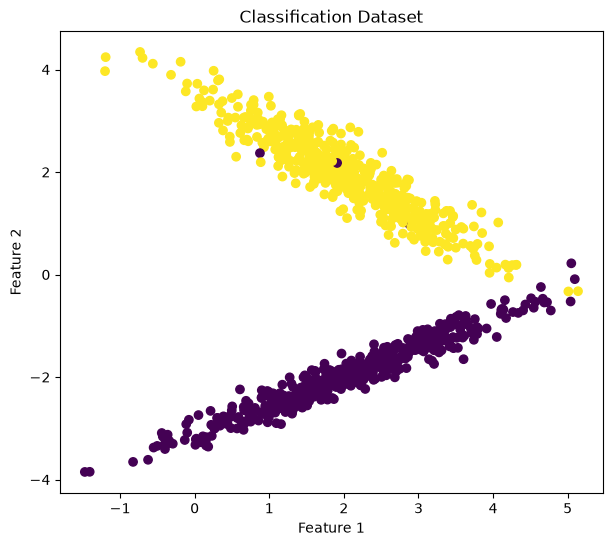

In [39]:
plt.figure(figsize=(7,6))

plt.scatter(
    df["Feature_1"],
    df["Feature_2"],
    c=df["Target"]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Classification Dataset")

plt.show()

In [40]:
X = df.drop("Target",axis=1)

y = df["Target"]

X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(800, 2)
(200, 2)


In [41]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [42]:
model = LogisticRegression()

model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [43]:
y_pred = model.predict(X_test)

In [44]:
y_prob = model.predict_proba(X_test)

print(y_prob[:5])

[[1.26734913e-02 9.87326509e-01]
 [9.99311073e-01 6.88926719e-04]
 [9.76194594e-01 2.38054060e-02]
 [9.98597203e-01 1.40279673e-03]
 [9.99210329e-01 7.89670937e-04]]


In [45]:
y_prob = model.predict_proba(X_test)[:,1]

In [46]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 0.995


In [47]:
cm = confusion_matrix(y_test,y_pred)

print(cm)

[[103   1]
 [  0  96]]


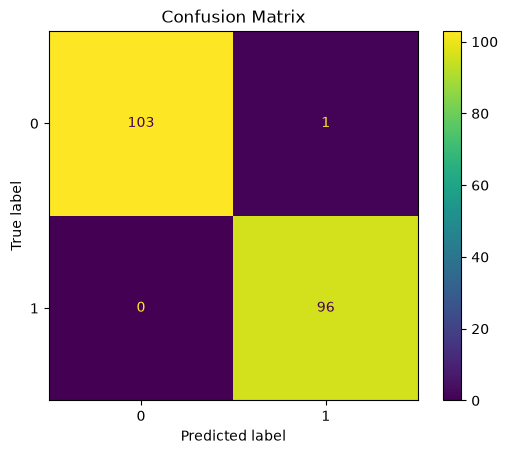

In [48]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

In [49]:
precision = precision_score(y_test,y_pred)

print("Precision :",precision)

Precision : 0.9896907216494846


In [50]:
recall = recall_score(y_test,y_pred)

print("Recall :",recall)

Recall : 1.0


In [51]:
f1 = f1_score(y_test,y_pred)

print("F1 Score :",f1)

F1 Score : 0.9948186528497409


In [52]:
balanced = balanced_accuracy_score(y_test,y_pred)

print("Balanced Accuracy :",balanced)

Balanced Accuracy : 0.9951923076923077


In [53]:
loss = log_loss(y_test,y_prob)

print("Log Loss :",loss)


Log Loss : 0.06325953407540127


In [54]:
mcc = matthews_corrcoef(y_test,y_pred)

print("Matthews Correlation Coefficient :",mcc)

Matthews Correlation Coefficient : 0.9900376077253566


In [55]:
kappa = cohen_kappa_score(y_test,y_pred)

print("Cohen Kappa :",kappa)

Cohen Kappa : 0.9899879855826993


In [56]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       1.00      0.99      1.00       104
           1       0.99      1.00      0.99        96

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



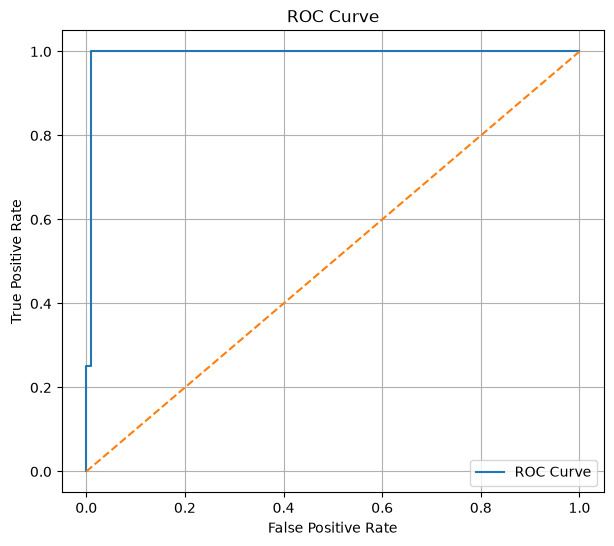

In [57]:
fpr,tpr,threshold = roc_curve(y_test,y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr,tpr,label="ROC Curve")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

In [58]:
auc = roc_auc_score(y_test,y_prob)

print("AUC Score :",auc)

AUC Score : 0.9927884615384616


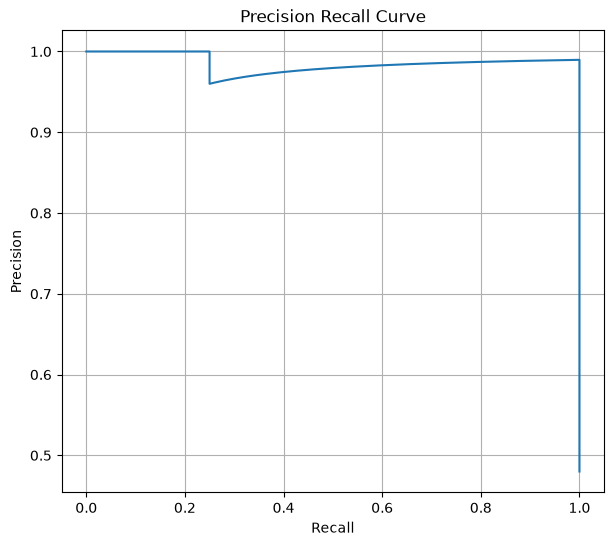

In [59]:
precision,recall,threshold = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,6))

plt.plot(recall,precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.grid()

plt.show()

In [60]:
performance = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "Balanced Accuracy",

        "Log Loss",

        "MCC",

        "Cohen Kappa",

        "AUC"

    ],

    "Value":[

        accuracy,

        precision_score(y_test,y_pred),

        recall_score(y_test,y_pred),

        f1_score(y_test,y_pred),

        balanced_accuracy_score(y_test,y_pred),

        log_loss(y_test,y_prob),

        matthews_corrcoef(y_test,y_pred),

        cohen_kappa_score(y_test,y_pred),

        roc_auc_score(y_test,y_prob)

    ]

})

performance

,Metric,Value
0,Accuracy,0.995000
1,Precision,0.989691
2,Recall,1.000000
3,F1 Score,0.994819
4,Balanced Accuracy,0.995192
5,Log Loss,0.063260
6,MCC,0.990038
7,Cohen Kappa,0.989988
8,AUC,0.992788


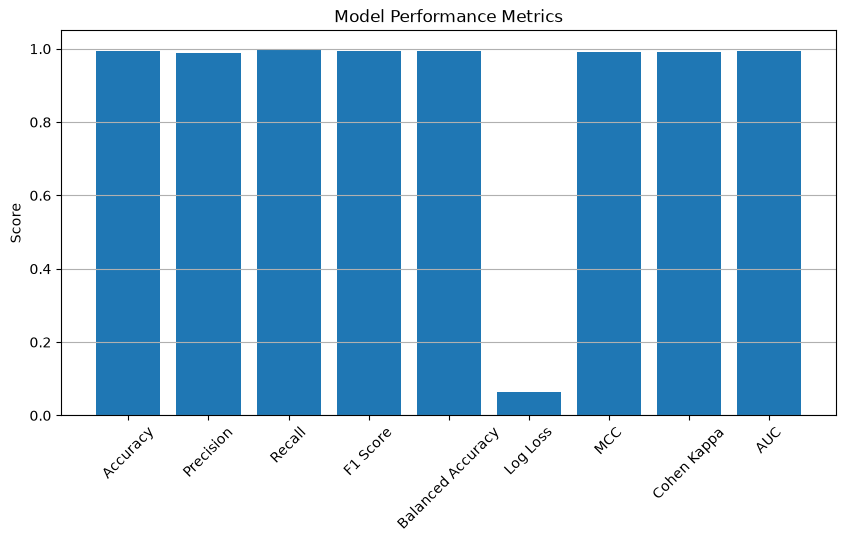

In [31]:
plt.figure(figsize=(10,5))

plt.bar(
    performance["Metric"],
    performance["Value"]
)

plt.xticks(rotation=45)

plt.title("Model Performance Metrics")

plt.ylabel("Score")

plt.grid(axis="y")

plt.show()